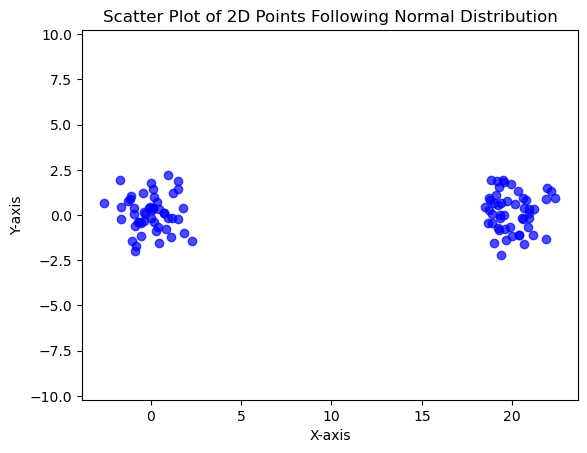

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # Seed for reproducibility
# Parameters
mean = [0, 0]  # Mean for x and y
std_dev = [1, 1]  # Standard deviation for x and y
num_points_per_cluster = 50  # Number of points to generate

# Generate points
points1 = np.random.normal(loc=[0, 0], scale=std_dev, size=(num_points_per_cluster, 2))
points3 = np.random.normal(loc=[20, 0], scale=std_dev, size=(num_points_per_cluster, 2))
X = np.vstack([points1, points3])

# Scatter plot
plt.scatter(X[:, 0], X[:, 1], alpha=0.7, color="blue")
plt.title("Scatter Plot of 2D Points Following Normal Distribution")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
# plt.grid()
plt.axis("equal")  # Ensure equal scaling
plt.show()

In [ ]:
import graph_mph


def compute_approximated_Hilbert_matrix(
    res: dict[str, list[tuple[int, int]]],
    table_x_coords: list[float],
    table_y_coords: list[float],
    target_matrix_shape: tuple[int, int],
):
    # convert the graded betti numbers in indices to filtration values
    b_0_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_0"], table_x_coords, table_y_coords
    )
    b_0_values = np.array(b_0_values)
    b_1_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_1"], table_x_coords, table_y_coords
    )
    b_1_values = np.array(b_1_values)
    b_2_values = graph_mph.map_graded_betti_numbers_to_filtration_values(
        res["b_2"], table_x_coords, table_y_coords
    )
    b_2_values = np.array(b_2_values)

    target_m, target_n = target_matrix_shape
    xs = np.linspace(table_x_coords[0], table_x_coords[-1], target_m)
    ys = np.linspace(table_y_coords[0], table_y_coords[-1], target_n)
    matrix_meshgrid = np.meshgrid(xs, ys, indexing="ij")

    cumsum_b_0 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_1 = np.zeros((target_m, target_n), dtype=np.int32)
    cumsum_b_2 = np.zeros((target_m, target_n), dtype=np.int32)
    for i in range(target_m):
        for j in range(target_n):
            s, k = matrix_meshgrid[0][i][j], matrix_meshgrid[1][i][j]
            # counts the number of rows (x,y) in b_0_values that satisfy x <= s and y <= k
            cumsum_b_0[i, j] = np.sum((b_0_values[:, 0] <= s) & (b_0_values[:, 1] <= k))
            cumsum_b_1[i, j] = np.sum((b_1_values[:, 0] <= s) & (b_1_values[:, 1] <= k))
            cumsum_b_2[i, j] = np.sum((b_2_values[:, 0] <= s) & (b_2_values[:, 1] <= k))

    return cumsum_b_0, cumsum_b_1, cumsum_b_2

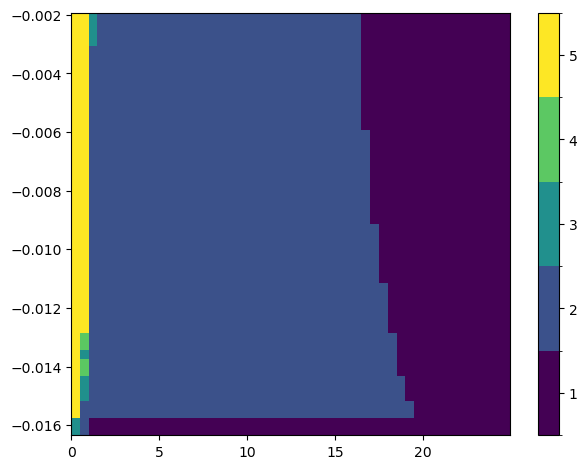

In [4]:
import graph_mph

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="ball_density",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    # file_path="../experiment/data/PointCloud/annulus_400.txt",
    points=X,
)

# then you can compute the MPH0 from the graded graph
graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # ball density function
table_y_coords = bifi.get_y_coords()  # distance

# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs ball density)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = graph_mph.draw_discrete_matrix(
    matrix_to_plot, x_axis_range=yrange, y_axis_range=xrange, origin="lower"
)
discrete_plot.tight_layout()
# discrete_plot.savefig("Hibert_matrix_ball_density_rips_blob_400.pdf", dpi=300)
discrete_plot.show()

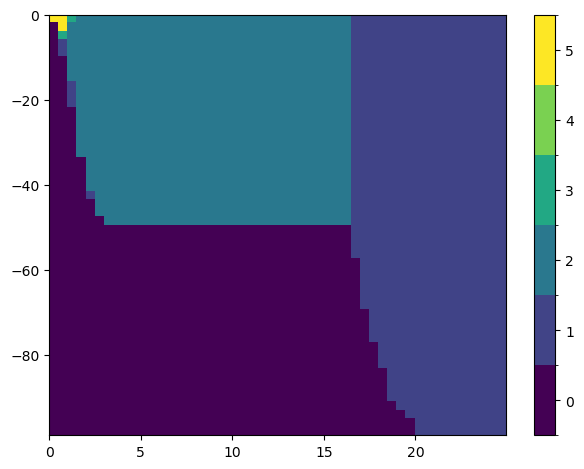

In [5]:
import graph_mph

# build a bi-filtration from a point cloud
bifi = graph_mph.BiFiltration(
    filtration_type="degree",  # filtration type can be "degree", "degree_rational", "ball_density", "ball_density_rational", "firep"
    # file_path="../experiment/data/PointCloud/annulus_400.txt",
    points=X,
)

# then you can compute the MPH0 from the graded graph
graded_graph = bifi.ggraph
res = graph_mph.compute_MPH0(graded_graph)

# in order to plot, you need to get the x and y coordinates of the points
table_x_coords = bifi.get_x_coords()  # distance
table_y_coords = bifi.get_y_coords()  # -degree

# compute the approximated Hilbert matrix
cum_0, cum_1, cum_2 = compute_approximated_Hilbert_matrix(
    res, table_x_coords, table_y_coords, (50, 50)
)

approx_hilbert_matrix = cum_0 - cum_1 + cum_2
# map the value greater to 4 to 4
approx_hilbert_matrix = np.clip(approx_hilbert_matrix, 0, 5)
# matrix_to_plot = np.log(approx_hilbert_matrix + 1)
matrix_to_plot = approx_hilbert_matrix

# plot the approximated Hilbert matrix (distance vs -degree)
xrange = np.min(table_x_coords), np.max(table_x_coords)
yrange = np.min(table_y_coords), np.max(table_y_coords)
discrete_plot, cbar = graph_mph.draw_discrete_matrix(
    matrix_to_plot.T, x_axis_range=xrange, y_axis_range=yrange, origin="lower"
)
discrete_plot.tight_layout()
# discrete_plot.savefig("Hibert_matrix_degree_rips_blob_400.pdf", dpi=300)
discrete_plot.show()